REGRESION MULTIVARIABLE

---
### Explicación del laboratorio – Regresión lineal multivariable





In [1]:
# 1. IMPORTACIÓN DE LIBRERÍAS


# PyTorch para construir y entrenar redes neuronales
import torch

# Para crear Dataset y DataLoader
from torch.utils.data import Dataset, DataLoader

# Librerías para manipulación de datos
import numpy as np
import pandas as pd

# Librería para gráficos
from matplotlib import pyplot as plt

# Barra de progreso para entrenamiento
from tqdm import tqdm

In [3]:
# 2. DETECTAR SI EXISTE GPU
# (concepto del cuadernillo 02)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Dispositivo utilizado:", device)

Dispositivo utilizado: cpu


In [4]:
# 3. MONTAR GOOGLE DRIVE (COLAB)

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# 4. CARGAR DATASET DE AIRBNB

data = pd.read_csv('/content/drive/MyDrive/colab/lab5/Copia de AB_NYC_2019.csv')

print("Primeras filas del dataset:")
display(data.head())

Primeras filas del dataset:


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [8]:
# 5. LIMPIEZA DE DATOS

# Eliminamos filas con valores faltantes
data = data.dropna()

# Seleccionamos características para el modelo
features = [
    'minimum_nights',
    'number_of_reviews',
    'reviews_per_month',
    'availability_365'
]
'''
minimum_nights → número mínimo de noches
number_of_reviews → cantidad de reseñas
reviews_per_month → reseñas por mes
availability_365 → disponibilidad en el año
'''

# Variable objetivo
target = 'price'

# Convertimos a arrays numpy
X = data[features].values
y = data[target].values

print("Forma de X:", X.shape)
print("Forma de y:", y.shape)

Forma de X: (38821, 4)
Forma de y: (38821,)


In [9]:
# 6. NORMALIZACIÓN DE DATOS

def normalizar(X):
# Función que normaliza las variables del dataset

    mu = np.mean(X, axis=0)
    # Calcula la media de cada variable (columna)

    sigma = np.std(X, axis=0)
    # Calcula la desviación estándar de cada variable

    X_norm = (X - mu) / sigma
    # Aplica la normalización:
    # resta la media y divide por la desviación estándar
    # esto hace que las variables tengan media 0 y varianza 1

    return X_norm, mu, sigma
    # Devuelve los datos normalizados, la media y la desviación


X_norm, mu, sigma = normalizar(X)
# Aplica la función de normalización al dataset X

print("Media:", mu)
# Muestra la media de cada variable

print("Desviación estándar:", sigma)
# Muestra la desviación estándar de cada variable

print("Datos normalizados correctamente.")

Media: [  5.86922027  29.29025527   1.37322918 114.88629865]
Desviación estándar: [ 17.38880228  48.18227934   1.68030613 129.52828165]
Datos normalizados correctamente.


In [10]:
# 7. DIVISIÓN DE DATOS

# 80% entrenamiento
split = int(len(X_norm) * 0.8)
# Calcula el índice donde se dividirán los datos
# 0.8 significa que el 80% será para entrenamiento

X_train = X_norm[:split]
# Toma el 80% inicial de los datos normalizados para entrenamiento

y_train = y[:split]
# Toma las etiquetas correspondientes al conjunto de entrenamiento

X_test = X_norm[split:]
# Toma el 20% restante de los datos para prueba

y_test = y[split:]
# Toma las etiquetas correspondientes al conjunto de prueba

print("Datos entrenamiento:", X_train.shape)
# Muestra el tamaño del dataset de entrenamiento

print("Datos prueba:", X_test.shape)
# Muestra el tamaño del dataset de prueba

print("División de datos completada (80% train / 20% test).")

Datos entrenamiento: (31056, 4)
Datos prueba: (7765, 4)
División de datos completada (80% train / 20% test).


In [11]:
# 8. CREAR DATASET PERSONALIZADO
# (concepto del cuadernillo 03)

class AirbnbDataset(Dataset):
# Creamos una clase de dataset personalizada para trabajar con PyTorch

    def __init__(self, X, y):
    # Constructor que recibe los datos de entrada (X) y las etiquetas (y)

        # Convertimos datos a tensores
        self.X = torch.from_numpy(X).float()
        # Convierte X (numpy) a tensor de PyTorch tipo float

        self.y = torch.from_numpy(y).float().view(-1,1)
        # Convierte y a tensor y lo reorganiza como columna (m x 1)

    # tamaño del dataset
    def __len__(self):
        return len(self.X)
        # Devuelve cuántos ejemplos tiene el dataset

    # obtener un elemento
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
        # Devuelve un ejemplo del dataset según el índice (X, y)

print("Dataset personalizado AirbnbDataset creado correctamente.")

Dataset personalizado AirbnbDataset creado correctamente.


In [12]:
# Creamos datasets
train_dataset = AirbnbDataset(X_train, y_train)
# Crea el dataset de entrenamiento usando la clase AirbnbDataset
# Contiene los datos X_train y sus precios correspondientes y_train

test_dataset = AirbnbDataset(X_test, y_test)
# Crea el dataset de prueba usando los datos X_test y y_test


print("Tamaño dataset entrenamiento:", len(train_dataset))
# Muestra cuántos ejemplos tiene el dataset de entrenamiento

print("Tamaño dataset prueba:", len(test_dataset))
# Muestra cuántos ejemplos tiene el dataset de prueba

print("Datasets creados correctamente.")

Tamaño dataset entrenamiento: 31056
Tamaño dataset prueba: 7765
Datasets creados correctamente.


In [13]:
# 9. CREAR DATALOADER
# (manejo automático de batches)

batch_size = 256
# Define cuántos ejemplos se procesarán en cada batch durante el entrenamiento

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
# Crea el DataLoader para entrenamiento
# train_dataset → dataset que creamos antes
# batch_size → número de ejemplos por batch
# shuffle=True → mezcla los datos en cada epoch para mejorar el aprendizaje

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)
# Crea el DataLoader para prueba
# shuffle=False porque en evaluación no es necesario mezclar los datos

print("DataLoaders creados correctamente.")
print("Batch size:", batch_size)

DataLoaders creados correctamente.
Batch size: 256


In [14]:
# 10. DEFINICIÓN DEL MODELO
# (RED NEURONAL PARA REGRESIÓN)

class RedRegresion(torch.nn.Module):
# Creamos una clase de red neuronal para resolver el problema de regresión

    def __init__(self):

        super().__init__()
        # Inicializa correctamente la clase base de PyTorch (Module)

        # capa entrada → capa oculta
        self.fc1 = torch.nn.Linear(4, 64)
        # Primera capa totalmente conectada
        # 4 → número de variables de entrada
        # 64 → número de neuronas en la primera capa oculta

        # activación
        self.relu = torch.nn.ReLU()
        # Función de activación ReLU para introducir no linealidad en la red

        # capa oculta → capa oculta
        self.fc2 = torch.nn.Linear(64, 32)
        # Segunda capa oculta
        # recibe 64 neuronas y produce 32

        # capa salida
        self.fc3 = torch.nn.Linear(32, 1)
        # Capa final que produce 1 valor
        # en regresión este valor es la predicción del precio


    def forward(self, x):
    # Define cómo fluye la información dentro de la red

        x = self.fc1(x)
        # Pasa los datos por la primera capa

        x = self.relu(x)
        # Aplica la activación ReLU

        x = self.fc2(x)
        # Pasa por la segunda capa oculta

        x = self.relu(x)
        # Aplica nuevamente la activación

        x = self.fc3(x)
        # Capa final que produce la predicción

        return x
        # Devuelve el valor predicho por la red


print("Modelo de red neuronal para regresión definido correctamente.")

Modelo de red neuronal para regresión definido correctamente.


In [15]:
# Creamos el modelo
model = RedRegresion().to(device)
# Instancia (crea) la red neuronal definida antes
# .to(device) envía el modelo al dispositivo disponible (CPU o GPU)

print(model)
# Muestra la arquitectura del modelo (capas y tamaños)

print("Modelo creado y cargado en:", device)

RedRegresion(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=1, bias=True)
)
Modelo creado y cargado en: cpu


In [16]:
# 11. FUNCIÓN DE PÉRDIDA Y OPTIMIZADOR

# Para regresión usamos MSE
criterion = torch.nn.MSELoss()
# Define la función de pérdida Mean Squared Error
# Mide el error cuadrático entre el valor real y el valor predicho por el modelo

# Optimizador
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
# Define el optimizador Adam que ajustará los pesos de la red neuronal
# model.parameters() → indica qué parámetros del modelo se deben actualizar
# lr=0.001 → tasa de aprendizaje (qué tan rápido aprende el modelo)

print("Función de pérdida (MSE) y optimizador (Adam) configurados.")

Función de pérdida (MSE) y optimizador (Adam) configurados.


In [17]:
# 12. FUNCIÓN PARA EVALUAR EL MODELO

def evaluar(model, dataloader):
# Función que evalúa el modelo en un dataset (sin entrenar)

    model.eval()
    # Coloca el modelo en modo evaluación (desactiva cosas como dropout)

    losses = []
    # Lista para guardar el error (loss) de cada batch

    with torch.no_grad():
    # Desactiva el cálculo de gradientes para ahorrar memoria y acelerar

        for X_batch, y_batch in dataloader:
        # Recorre los datos por batches

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            # Envía los datos al dispositivo (CPU o GPU)

            y_pred = model(X_batch)
            # El modelo genera predicciones

            loss = criterion(y_pred, y_batch)
            # Calcula el error entre predicción y valor real

            losses.append(loss.item())
            # Guarda el valor numérico del error

    print("Evaluación completada. Loss promedio:", np.mean(losses))
    # Muestra el error promedio del modelo en ese dataset

    return np.mean(losses)
    # Devuelve el loss promedio

In [18]:
# 13. ENTRENAMIENTO DEL MODELO

def entrenar(model, train_loader, test_loader, epochs=30, PATH="./checkpoint_regresion.pt"):
# Función que entrena la red neuronal y guarda el mejor modelo

    model.to(device)
    # Envía el modelo al dispositivo disponible (CPU o GPU)

    best_loss = float("inf")
    # Inicializa el mejor error con infinito
    # así el primer modelo siempre será mejor y se guardará

    train_history = []
    test_history = []
    # Listas para guardar la evolución del error en entrenamiento y prueba

    for epoch in range(1, epochs+1):
    # Bucle principal de entrenamiento por épocas

        model.train()
        # Coloca el modelo en modo entrenamiento

        train_losses = []
        # Lista para guardar el loss de cada batch

        barra = tqdm(train_loader)
        # Barra de progreso para visualizar el entrenamiento

        for X_batch, y_batch in barra:
        # Recorre los datos de entrenamiento por batches

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)
            # Envía los datos al dispositivo

            # Forward
            y_pred = model(X_batch)
            # El modelo genera predicciones

            # Calcular pérdida
            loss = criterion(y_pred, y_batch)
            # Calcula el error entre el valor real y el predicho

            # Reiniciar gradientes
            optimizer.zero_grad()
            # Limpia los gradientes acumulados de la iteración anterior

            # Backpropagation
            loss.backward()
            # Calcula los gradientes usando backpropagation

            # Actualizar pesos
            optimizer.step()
            # Ajusta los pesos del modelo para reducir el error

            train_losses.append(loss.item())
            # Guarda el valor numérico del error

            barra.set_description(f"loss {np.mean(train_losses):.4f}")
            # Actualiza la barra mostrando el loss promedio actual

        # evaluar en conjunto de prueba
        test_loss = evaluar(model, test_loader)
        # Evalúa el modelo usando el dataset de prueba

        train_loss = np.mean(train_losses)
        # Calcula el error promedio de entrenamiento en esta época

        train_history.append(train_loss)
        test_history.append(test_loss)
        # Guarda el historial de errores para gráficas posteriores

        print(f"Epoch {epoch}/{epochs}  Train Loss: {train_loss:.4f}  Test Loss: {test_loss:.4f}")
        # Muestra el progreso del entrenamiento

        # guardar mejor modelo
        if test_loss < best_loss:
        # Si el error en test mejora

            best_loss = test_loss
            # Actualiza el mejor error encontrado

            torch.save(model.state_dict(), PATH)
            # Guarda los pesos del mejor modelo

            print("Mejor modelo guardado")

    # cargar el mejor modelo al final
    model.load_state_dict(torch.load(PATH))
    # Carga los mejores pesos guardados durante el entrenamiento

    return train_history, test_history
    # Devuelve el historial de errores para entrenamiento y prueba


# Ejecutamos entrenamiento

train_loss, test_loss = entrenar(model, train_loader, test_loader)
# Llama a la función para comenzar el entrenamiento del modelo

print("Entrenamiento finalizado.")
print("Loss final entrenamiento:", train_loss[-1])
print("Loss final prueba:", test_loss[-1])

loss 57771.0794: 100%|██████████| 122/122 [00:01<00:00, 117.37it/s]


Evaluación completada. Loss promedio: 54469.15776209677
Epoch 1/30  Train Loss: 57771.0794  Test Loss: 54469.1578
Mejor modelo guardado


loss 48267.0496: 100%|██████████| 122/122 [00:00<00:00, 177.12it/s]


Evaluación completada. Loss promedio: 40837.65012285786
Epoch 2/30  Train Loss: 48267.0496  Test Loss: 40837.6501
Mejor modelo guardado


loss 40731.3581: 100%|██████████| 122/122 [00:00<00:00, 187.01it/s]


...

Evaluación completada. Loss promedio: 35016.42412739415
Epoch 28/30  Train Loss: 38994.6840  Test Loss: 35016.4241


loss 38985.3355: 100%|██████████| 122/122 [00:00<00:00, 144.89it/s]


Evaluación completada. Loss promedio: 34979.88920740927
Epoch 29/30  Train Loss: 38985.3355  Test Loss: 34979.8892
Mejor modelo guardado


loss 39482.6108: 100%|██████████| 122/122 [00:00<00:00, 131.48it/s]


Evaluación completada. Loss promedio: 34978.97462512601
Epoch 30/30  Train Loss: 39482.6108  Test Loss: 34978.9746
Mejor modelo guardado
Entrenamiento finalizado.
Loss final entrenamiento: 39482.61083984375
Loss final prueba: 34978.97462512601


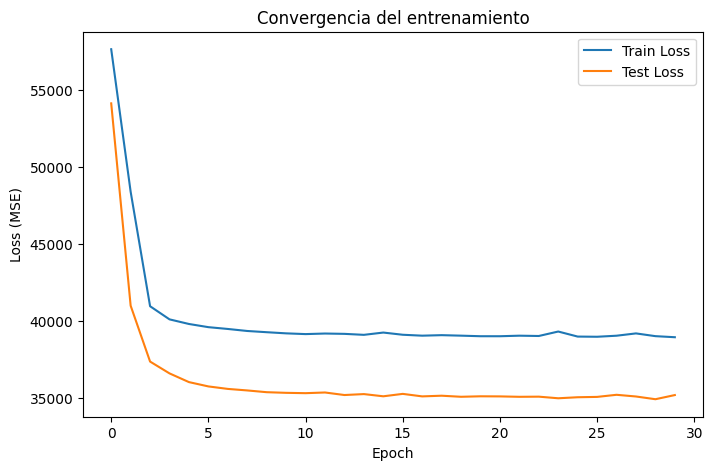

In [16]:
# 14. GRÁFICA DE CONVERGENCIA DEL ENTRENAMIENTO

plt.figure(figsize=(8,5))

plt.plot(train_loss, label="Train Loss")
plt.plot(test_loss, label="Test Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Convergencia del entrenamiento")

plt.legend()

plt.show()

In [19]:
# 15. FUNCIÓN PARA REALIZAR PREDICCIONES

def predecir(model, X_data):
# Función que usa el modelo entrenado para generar predicciones

    model.eval()
    # Coloca el modelo en modo evaluación (no entrena)

    with torch.no_grad():
    # Desactiva el cálculo de gradientes para acelerar la predicción

        # Convertir a tensor de PyTorch y mover al dispositivo
        X_tensor = torch.from_numpy(X_data).float().to(device)
        # Convierte los datos de numpy a tensor y los envía a CPU/GPU

        # Realizar predicción
        pred = model(X_tensor)
        # El modelo genera valores predichos (precio estimado)

        # Convertir la predicción de nuevo a numpy
        return pred.cpu().numpy()
        # Devuelve las predicciones en formato numpy


# 16. PREDICCIONES DEL MODELO


predicciones = predecir(model, X_norm)
# Usa la función predecir() para generar predicciones sobre todo el dataset

predicciones = predicciones.flatten()
# Convierte las predicciones a un vector 1D para facilitar su visualización

print("Primeras predicciones:")
print(predicciones[:10])
# Muestra las primeras 10 predicciones del modelo

print("Total de predicciones generadas:", len(predicciones))

Primeras predicciones:
[194.6452  183.23822 125.04571 134.74434 153.6652  147.37602 145.28447
 137.31229 150.79262 134.94963]
Total de predicciones generadas: 38821


In [20]:
# 19. PREDICCIÓN DE UN NUEVO EJEMPLO

nuevo = np.array([
    [
        (3 - mu[0]) / sigma[0],      # minimum_nights
        # Normaliza el valor 3 usando la media y desviación de la variable minimum_nights

        (10 - mu[1]) / sigma[1],     # number_of_reviews
        # Normaliza el valor 10 de la variable number_of_reviews

        (1 - mu[2]) / sigma[2],      # reviews_per_month
        # Normaliza el valor 1 de la variable reviews_per_month

        (200 - mu[3]) / sigma[3]     # availability_365
        # Normaliza el valor 200 de la variable availability_365
    ]
])
# Crea un nuevo ejemplo con las 4 variables del modelo ya normalizadas

precio_predicho = predecir(model, nuevo)
# Usa el modelo entrenado para predecir el precio estimado del alojamiento

print("Precio predicho:", precio_predicho[0][0])
# Muestra el valor predicho por el modelo

print("Predicción realizada correctamente para un nuevo ejemplo.")

Precio predicho: 160.18843
Predicción realizada correctamente para un nuevo ejemplo.


In [21]:
# 21. MÉTRICAS DE PRECISIÓN DEL MODELO

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
# Importa métricas para evaluar modelos de regresión

# Calculamos métricas

mae = mean_absolute_error(y, predicciones)
# MAE: promedio del error absoluto entre valores reales y predichos
# (qué tan lejos está en promedio la predicción del valor real)

mse = mean_squared_error(y, predicciones)
# MSE: promedio del error al cuadrado
# penaliza más los errores grandes

rmse = np.sqrt(mse)
# RMSE: raíz del MSE
# está en la misma escala que los datos (más interpretable)

r2 = r2_score(y, predicciones)
# R²: mide qué tan bien el modelo explica los datos
# 1 = perfecto, 0 = modelo malo

print("MAE (Error absoluto medio):", mae)
# Muestra el error promedio en valor absoluto

print("RMSE (Error cuadrático medio):", rmse)
# Muestra el error cuadrático en la misma escala del problema

print("R2 Score:", r2)
# Muestra qué tan bueno es el modelo (entre 0 y 1)

print("Evaluación del modelo de regresión completada.")

MAE (Error absoluto medio): 79.7061996459961
RMSE (Error cuadrático medio): 195.9948679972259
R2 Score: 0.010100185871124268
Evaluación del modelo de regresión completada.


In [22]:
# 23. OTRO EJEMPLO DE PREDICCIÓN

# ejemplo de un departamento diferente

nuevo2 = np.array([
    [
        (7 - mu[0]) / sigma[0],      # minimum_nights
        (25 - mu[1]) / sigma[1],     # number_of_reviews
        (2 - mu[2]) / sigma[2],      # reviews_per_month
        (150 - mu[3]) / sigma[3]     # availability_365
    ]
])

precio_predicho2 = predecir(model, nuevo2)

print("Precio predicho del segundo ejemplo:", precio_predicho2[0][0])

Precio predicho del segundo ejemplo: 136.72807
